# EDA — Violencia Intrafamiliar Colombia 2015–2024

**Dataset:** `Violencia_intrafamiliar._Colombia,_años_2015_a_2024._Cifras_definitivas_20260217.csv`

El análisis sigue este flujo:
1. Carga y exploración inicial
2. Categorización de columnas
3. Manejo de nulos y valores especiales
4. Detección de datos atípicos
5. EDA con 3 preguntas clave

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Carga del dataset ──────────────────────────────────────────────────────────
CSV_PATH = 'Violencia_intrafamiliar._Colombia,_años_2015_a_2024._Cifras_definitivas_20260217.csv'
df = pd.read_csv(CSV_PATH)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas:\n{list(df.columns)}")
df.head(3)

Dimensiones: 236,840 filas × 36 columnas

Columnas:
['ID', 'Año del hecho', 'Sexo de la victima', 'Grupo de edad quinquenal', 'Grupo Mayor Menor de Edad', 'Grupo de Edad judicial', 'Ciclo Vital', 'País de Nacimiento', 'Escolaridad', 'Estado Civil', 'Tipo de Discapacidad', 'Pertenencia Étnica', 'Orientación Sexual', 'Identidad de Género', 'Transgénero', 'Pertenencia Grupal', 'Mes del hecho', 'Dia del hecho', 'Rango de Hora del Hecho X 3 Horas', 'Código Dane Municipio', 'Municipio del hecho DANE', 'Departamento del hecho DANE', 'Código Dane Departamento', 'Localidad del Hecho', 'Zona del Hecho', 'Escenario del Hecho', 'Actividad Durante el Hecho', 'Circunstancia del Hecho Detallada', 'Contexto del Hecho', 'Mecanismo Causal de la Lesión no Fatal', 'Diagnostico Topográfico de la Lesión no Fatal', 'Sexo del Agresor', 'Presunto Agresor Detallado', 'Factor Desencadenante de la Agresión', 'Días de Incapacidad Medicolegal', 'Pueblo Indígena']


,ID,Año del hecho,Sexo de la victima,Grupo de edad quinquenal,Grupo Mayor Menor de Edad,Grupo de Edad judicial,Ciclo Vital,País de Nacimiento,Escolaridad,Estado Civil,...,Actividad Durante el Hecho,Circunstancia del Hecho Detallada,Contexto del Hecho,Mecanismo Causal de la Lesión no Fatal,Diagnostico Topográfico de la Lesión no Fatal,Sexo del Agresor,Presunto Agresor Detallado,Factor Desencadenante de la Agresión,Días de Incapacidad Medicolegal,Pueblo Indígena
0,1,2015,Hombre,(10 a 14),a) Menor de Edad (<18 Años),(10 a 13),(12 a 17) Adolescencia,Colombia,Básica primaria,Soltero (a),...,Actividades de desplazamiento de un lugar a otro.,"Violencia contra niños, niñas y adolescentes","3 Lesiones no Fatales contra Niños, Niñas y Ad...",Abrasivo,Trauma de miembros,Hombre,Padre,"Intolerancia, machismo",1 a 30,No había sido implementada
1,2,2015,Hombre,(00 a 04),a) Menor de Edad (<18 Años),(00 a 04),(00 a 05) Primera Infancia,Colombia,No aplica,No aplica,...,Actividades relacionadas con la asistencia a e...,"Violencia contra niños, niñas y adolescentes","3 Lesiones no Fatales contra Niños, Niñas y Ad...",Contundente,Trauma de miembros,Mujer,Madre,"Intolerancia, machismo",1 a 30,No había sido implementada
2,3,2015,Hombre,(00 a 04),a) Menor de Edad (<18 Años),(00 a 04),(00 a 05) Primera Infancia,Colombia,No aplica,No aplica,...,Actividades de desplazamiento de un lugar a otro.,"Violencia contra niños, niñas y adolescentes","3 Lesiones no Fatales contra Niños, Niñas y Ad...",Por determinar,Sin información,Mujer,Otros familiares civiles o consanguineos,"Intolerancia, machismo",Sin información,No había sido implementada


In [41]:
print("=== TIPOS DE DATOS ORIGINALES ===")
print(df.dtypes)
print(f"\n=== NULOS REALES (NaN) ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay nulos reales en el dataset.")
print(f"\n=== RESUMEN ESTADÍSTICO (columnas numéricas) ===")
df.describe()

=== TIPOS DE DATOS ORIGINALES ===
ID                                                int64
Año del hecho                                     int64
Sexo de la victima                               object
Grupo de edad quinquenal                         object
Grupo Mayor Menor de Edad                        object
Grupo de Edad judicial                           object
Ciclo Vital                                      object
País de Nacimiento                               object
Escolaridad                                      object
Estado Civil                                     object
Tipo de Discapacidad                             object
Pertenencia Étnica                               object
Orientación Sexual                               object
Identidad de Género                              object
Transgénero                                      object
Pertenencia Grupal                               object
Mes del hecho                                    object
Dia del hecho 

,ID,Año del hecho,Código Dane Municipio,Código Dane Departamento
count,236840.000000,236840.000000,236840.000000,236840.000000
mean,118420.500000,2019.161687,31485.458825,31.360889
std,68369.963215,2.874819,26841.322577,27.469980
min,1.000000,2015.000000,999.000000,5.000000
25%,59210.750000,2017.000000,11001.000000,11.000000
50%,118420.500000,2019.000000,17001.000000,17.000000
75%,177630.250000,2022.000000,54001.000000,54.000000
max,236840.000000,2024.000000,99773.000000,999.000000


## 2. Categorización de columnas

El dataset tiene:
- **Columnas identificadoras** (no categorizables): `ID`, `Código Dane Municipio`, `Código Dane Departamento`
- **Columna numérica continua**: `Año del hecho`
- **Columnas categóricas**: todas las demás (variables nominales u ordinales)

> `Días de Incapacidad Medicolegal` es **ordinal-categórica** (rangos como "1 a 30", "31 a 90"), no numérica real.

In [42]:
# ── Definición de grupos de columnas ──────────────────────────────────────────
ID_COLS   = ['ID', 'Código Dane Municipio', 'Código Dane Departamento']
NUM_COLS  = ['Año del hecho']
CAT_COLS  = [c for c in df.columns if c not in ID_COLS + NUM_COLS]

# Orden ordinal para días de incapacidad
ORDEN_DIAS = ['Sin información', '1 a 30', '31 a 90', '91 a 180', 'Más de 180']

# ── Conversión a categorías ────────────────────────────────────────────────────
for col in CAT_COLS:
    if col == 'Días de Incapacidad Medicolegal':
        cat_type = pd.CategoricalDtype(
            categories=[x for x in ORDEN_DIAS if x in df[col].unique()],
            ordered=True
        )
        df[col] = df[col].astype(cat_type)
    else:
        df[col] = df[col].astype('category')

print(f"Columnas categóricas: {len(CAT_COLS)}")
print(f"Columnas numéricas  : {len(NUM_COLS)}")
print(f"Columnas ID         : {len(ID_COLS)}")
print("\nTipos tras categorización:")
print(df[CAT_COLS[:6]].dtypes)  # muestra una selección

Columnas categóricas: 32
Columnas numéricas  : 1
Columnas ID         : 3

Tipos tras categorización:
Sexo de la victima           category
Grupo de edad quinquenal     category
Grupo Mayor Menor de Edad    category
Grupo de Edad judicial       category
Ciclo Vital                  category
País de Nacimiento           category
dtype: object


## 3. Manejo de nulos y valores especiales

En este dataset **no hay NaN reales**, pero existen valores que representan falta de información:
- `"Sin información"` — dato no disponible
- `"No Sabe / No Informa"` — víctima/agresor no lo reportó
- `"No aplica"` — categoría lógicamente no aplicable (ej. orientación sexual en menores)

**Estrategia:**
- Se mantiene el `df` original con todos los valores (útil para conteos totales).
- Se crea `df_clean` donde estos valores se reemplazan por `NaN` para análisis que requieran datos válidos.

                                                    n     %
Grupo de edad quinquenal                            5   0.0
Grupo de Edad judicial                              5   0.0
Ciclo Vital                                         5   0.0
Departamento del hecho DANE                         9   0.0
Municipio del hecho DANE                            9   0.0
Circunstancia del Hecho Detallada                 332   0.1
País de Nacimiento                                487   0.2
Actividad Durante el Hecho                       1978   0.8
Presunto Agresor Detallado                       2040   0.9
Escenario del Hecho                              2104   0.9
Sexo del Agresor                                 2491   1.1
Zona del Hecho                                   5775   2.4
Escolaridad                                      6996   3.0
Días de Incapacidad Medicolegal                 10078   4.3
Factor Desencadenante de la Agresión            16881   7.1
Diagnostico Topográfico de la Lesión no 

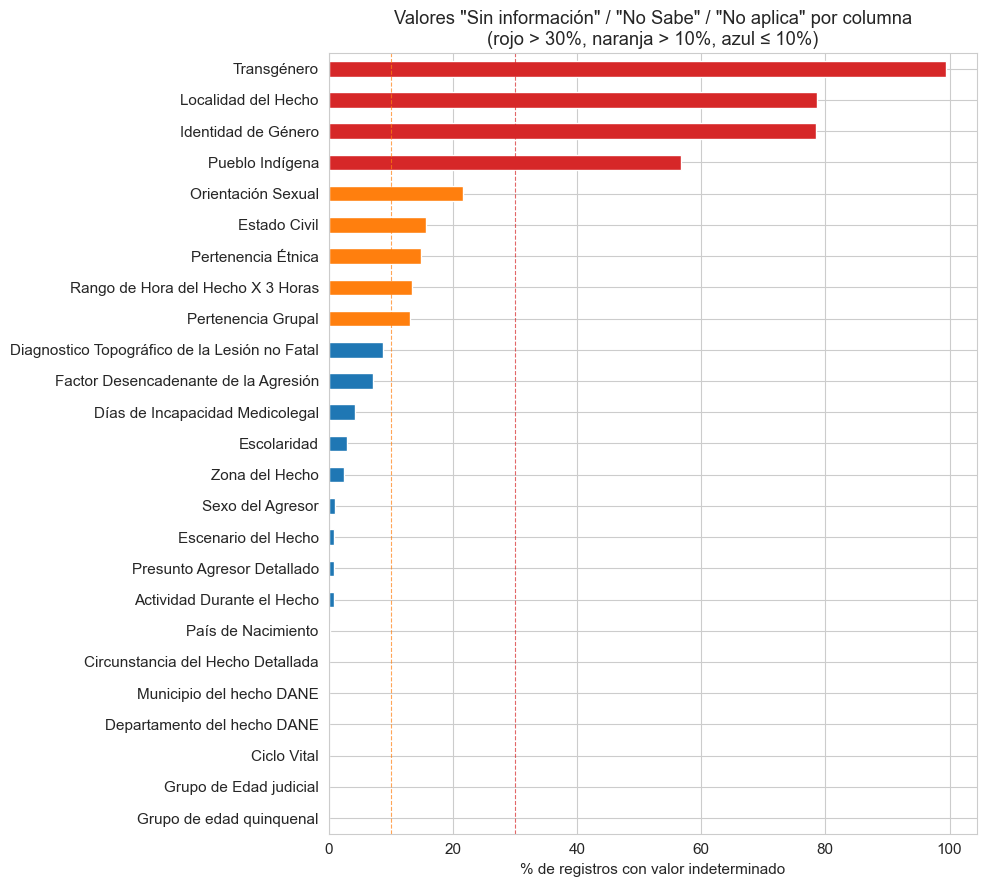

In [43]:
VALORES_NULOS = {'Sin información', 'No Sabe / No Informa', 'No aplica'}

# ── Análisis de presencia de valores especiales ───────────────────────────────
registros_afectados = {}
for col in CAT_COLS:
    n = df[col].astype(str).isin(VALORES_NULOS).sum()
    if n > 0:
        registros_afectados[col] = n

sin_info_series = (
    pd.Series(registros_afectados)
    .sort_values(ascending=True)
    .rename('n')
)
sin_info_pct = (sin_info_series / len(df) * 100).rename('%')

resumen_nulos = pd.concat([sin_info_series, sin_info_pct.round(1)], axis=1)
print(resumen_nulos.to_string())

# ── Visualización ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
colores = ['#d62728' if p > 30 else '#ff7f0e' if p > 10 else '#1f77b4'
           for p in sin_info_pct]
sin_info_pct.plot(kind='barh', ax=ax, color=colores)
ax.set_xlabel('% de registros con valor indeterminado')
ax.set_title('Valores "Sin información" / "No Sabe" / "No aplica" por columna\n'
             '(rojo > 30%, naranja > 10%, azul ≤ 10%)')
ax.axvline(30, color='#d62728', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(10, color='#ff7f0e', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
# ── Crear df_clean con NaN en lugar de valores especiales ─────────────────────
df_clean = df.copy()

for col in CAT_COLS:
    mask = df_clean[col].astype(str).isin(VALORES_NULOS)
    if mask.any():
        # Convertir a object, asignar NaN, reconvertir a category
        temp = df_clean[col].astype(object)
        temp.loc[mask] = np.nan
        df_clean[col] = temp.astype('category')

print("Nulos en df_clean (Top 15 columnas con más nulos):")
nulos_clean = df_clean[CAT_COLS].isnull().sum().sort_values(ascending=False)
pct_clean = (nulos_clean[nulos_clean > 0] / len(df_clean) * 100).round(1)
print(pct_clean.head(15).to_string())
print(f"\nTotal registros: {len(df_clean):,}")
print(f"df_clean creado correctamente ✓")

Nulos en df_clean (Top 15 columnas con más nulos):
Transgénero                                      99.4
Localidad del Hecho                              78.7
Identidad de Género                              78.5
Pueblo Indígena                                  56.7
Orientación Sexual                               21.6
Días de Incapacidad Medicolegal                  21.0
Estado Civil                                     15.7
Pertenencia Étnica                               14.8
Rango de Hora del Hecho X 3 Horas                13.5
Pertenencia Grupal                               13.1
Diagnostico Topográfico de la Lesión no Fatal     8.7
Factor Desencadenante de la Agresión              7.1
Escolaridad                                       3.0
Zona del Hecho                                    2.4
Sexo del Agresor                                  1.1

Total registros: 236,840
df_clean creado correctamente ✓


## 4. Detección de datos atípicos

**Variable numérica continua — `Año del hecho`:**  
Se espera un rango de 2015 a 2024; cualquier valor fuera de ese rango sería atípico.

**Variable ordinal — `Días de Incapacidad Medicolegal`:**  
Es categórica-ordinal (rangos textuales). Se analiza la distribución de categorías para detectar categorías inesperadas o dominantes.

Registros fuera del rango 2015–2024: 0  → SIN atípicos ✓
count    236840.000000
mean       2019.161687
std           2.874819
min        2015.000000
25%        2017.000000
50%        2019.000000
75%        2022.000000
max        2024.000000


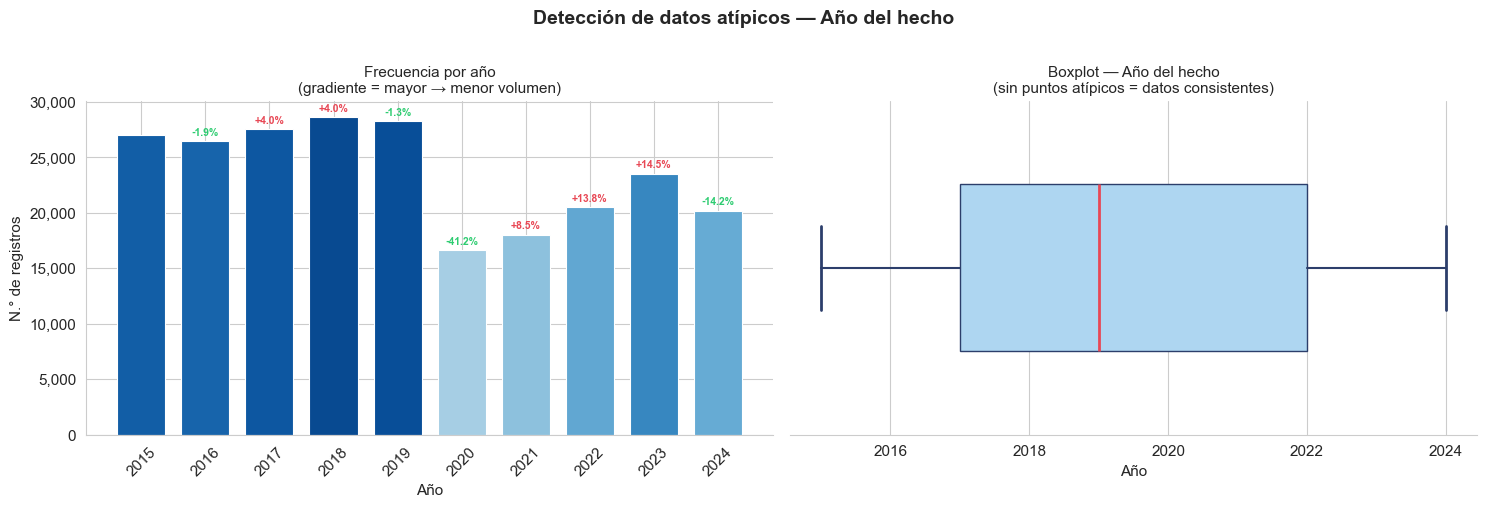

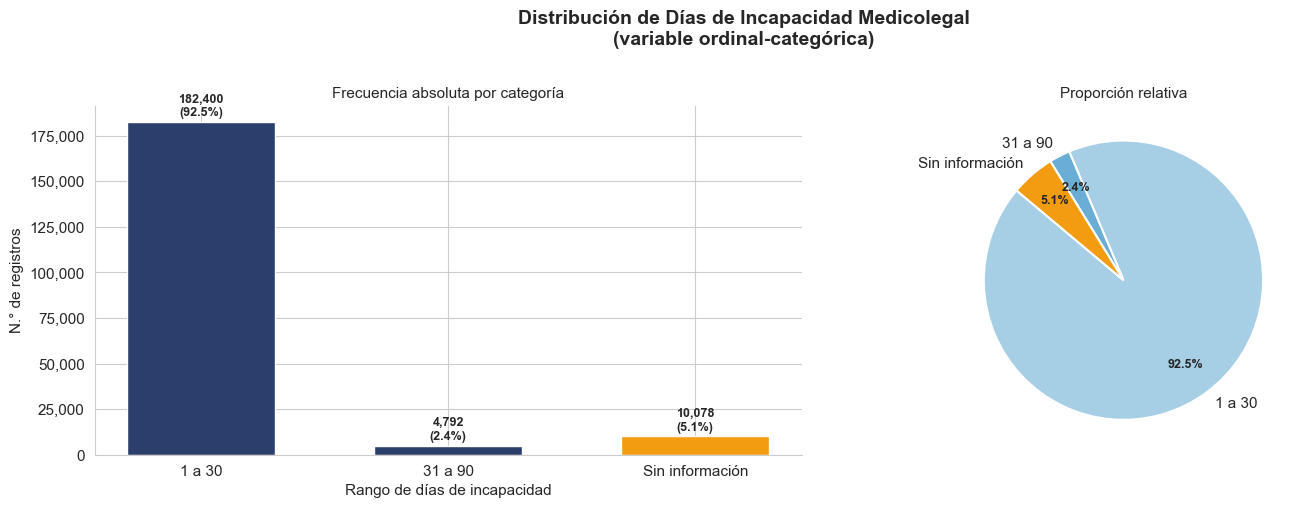

In [45]:
PALETTE = {'base': '#2C3E6B', 'accent': '#E84855', 'ok': '#2ECC71', 'warn': '#F39C12'}

# ── 1. Año del hecho ──────────────────────────────────────────────────────────
conteo_anio = df['Año del hecho'].value_counts().sort_index()
anios_fuera  = df[(df['Año del hecho'] < 2015) | (df['Año del hecho'] > 2024)]
print(f"Registros fuera del rango 2015–2024: {len(anios_fuera)}  → {'SIN atípicos ✓' if len(anios_fuera)==0 else '⚠ Revisar'}")
print(df['Año del hecho'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Detección de datos atípicos — Año del hecho', fontsize=14, fontweight='bold', y=1.01)

# Barras con gradiente de color por año
cmap = plt.cm.Blues
norm_vals = (conteo_anio.values - conteo_anio.min()) / (conteo_anio.max() - conteo_anio.min())
bar_colors = [cmap(0.35 + 0.55 * v) for v in norm_vals]

bars = axes[0].bar(conteo_anio.index.astype(str), conteo_anio.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8, width=0.75)
axes[0].set_title('Frecuencia por año\n(gradiente = mayor → menor volumen)', fontsize=11)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('N.° de registros')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)
# Anotación del cambio % respecto al año anterior
for i, (bar, val) in enumerate(zip(bars, conteo_anio.values)):
    if i > 0:
        cambio = (val - conteo_anio.values[i-1]) / conteo_anio.values[i-1] * 100
        color_txt = PALETTE['ok'] if cambio < 0 else PALETTE['accent']
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + conteo_anio.max()*0.012,
                     f'{cambio:+.1f}%', ha='center', va='bottom',
                     fontsize=7.5, color=color_txt, fontweight='bold')

# Boxplot estilizado
bp = axes[1].boxplot(df['Año del hecho'], vert=False, patch_artist=True,
                     widths=0.5,
                     boxprops=dict(facecolor='#AED6F1', color=PALETTE['base']),
                     medianprops=dict(color=PALETTE['accent'], linewidth=2),
                     whiskerprops=dict(color=PALETTE['base'], linewidth=1.5),
                     capprops=dict(color=PALETTE['base'], linewidth=2),
                     flierprops=dict(marker='o', color=PALETTE['accent'],
                                     markerfacecolor=PALETTE['accent'], markersize=6))
axes[1].set_title('Boxplot — Año del hecho\n(sin puntos atípicos = datos consistentes)', fontsize=11)
axes[1].set_xlabel('Año')
axes[1].spines[['top','right','left']].set_visible(False)
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('atipicos_anio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Días de Incapacidad (ordinal-categórica) ───────────────────────────────
ORDEN_DISPLAY = [c for c in ['1 a 30', '31 a 90', '91 a 180', 'Más de 180', 'Sin información']
                 if c in df['Días de Incapacidad Medicolegal'].astype(str).unique()]
dist_dias = df['Días de Incapacidad Medicolegal'].astype(str).value_counts().reindex(ORDEN_DISPLAY, fill_value=0)
pct_dias  = (dist_dias / dist_dias.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribución de Días de Incapacidad Medicolegal\n(variable ordinal-categórica)',
             fontsize=14, fontweight='bold', y=1.01)

# Barras con color diferenciado para "Sin información"
bar_c = [PALETTE['warn'] if lbl == 'Sin información' else PALETTE['base'] for lbl in ORDEN_DISPLAY]
bars2 = axes[0].bar(ORDEN_DISPLAY, dist_dias.values, color=bar_c, edgecolor='white', width=0.6)
axes[0].set_title('Frecuencia absoluta por categoría', fontsize=11)
axes[0].set_xlabel('Rango de días de incapacidad')
axes[0].set_ylabel('N.° de registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)
for bar, val, p in zip(bars2, dist_dias.values, pct_dias.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + dist_dias.max()*0.01,
                 f'{val:,}\n({p}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie
pie_colors = [PALETTE['warn'] if lbl == 'Sin información' else c
              for lbl, c in zip(ORDEN_DISPLAY, plt.cm.Blues(
                  [0.35, 0.5, 0.65, 0.8, 0.95][:len(ORDEN_DISPLAY)]))]
wedges, texts, autotexts = axes[1].pie(
    dist_dias.values, labels=ORDEN_DISPLAY, autopct='%1.1f%%',
    colors=pie_colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[1].set_title('Proporción relativa', fontsize=11)

plt.tight_layout()
plt.savefig('atipicos_incapacidad.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EDA — Preguntas clave

### Pregunta 1: ¿Cómo ha evolucionado la violencia intrafamiliar en Colombia entre 2015 y 2024, y qué departamentos concentran más casos?

*Motivación:* Entender la tendencia temporal permite detectar si el fenómeno crece, decrece o tiene picos vinculados a eventos (ej. pandemia 2020). La distribución geográfica revela dónde enfocar las políticas públicas.

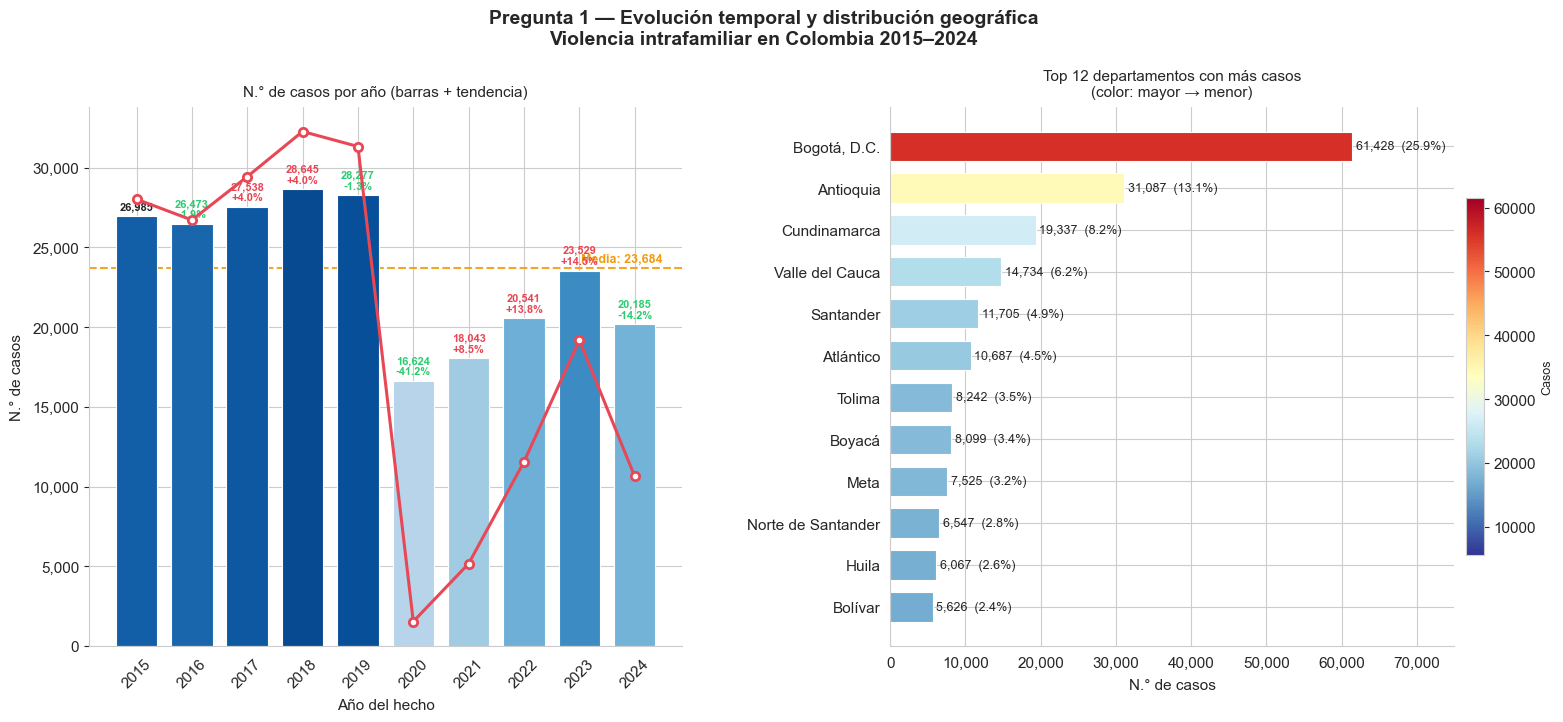

In [46]:
fig = plt.figure(figsize=(18, 7))
gs  = fig.add_gridspec(1, 2, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
fig.suptitle('Pregunta 1 — Evolución temporal y distribución geográfica\n'
             'Violencia intrafamiliar en Colombia 2015–2024',
             fontsize=14, fontweight='bold', y=1.02)

# ── Evolución temporal (combo bar + línea) ────────────────────────────────────
casos_anio = df.groupby('Año del hecho').size().reset_index(name='casos')
cmap2 = plt.cm.Blues
norm2 = (casos_anio['casos'] - casos_anio['casos'].min()) / (casos_anio['casos'].max() - casos_anio['casos'].min())
bar_c2 = [cmap2(0.3 + 0.6 * v) for v in norm2]

bars = ax1.bar(casos_anio['Año del hecho'].astype(str), casos_anio['casos'],
               color=bar_c2, edgecolor='white', linewidth=0.8, width=0.75, zorder=2)
ax1_twin = ax1.twinx()
ax1_twin.plot(range(len(casos_anio)), casos_anio['casos'],
              color=PALETTE['accent'], marker='o', linewidth=2.2, zorder=3,
              markersize=6, markerfacecolor='white', markeredgewidth=2)
ax1_twin.set_yticks([])
ax1_twin.spines[['top','right','bottom','left']].set_visible(False)

# Línea de media
media = casos_anio['casos'].mean()
ax1.axhline(media, color=PALETTE['warn'], linestyle='--', linewidth=1.5, alpha=0.9, zorder=1)
ax1.text(len(casos_anio) - 0.5, media + casos_anio['casos'].max()*0.015,
         f'Media: {media:,.0f}', ha='right', fontsize=9, color=PALETTE['warn'], fontweight='bold')

# Etiquetas con variación %
for i, (bar, row) in enumerate(zip(bars, casos_anio.itertuples())):
    pct_txt = ''
    if i > 0:
        cambio = (row.casos - casos_anio.iloc[i-1]['casos']) / casos_anio.iloc[i-1]['casos'] * 100
        col_t = PALETTE['accent'] if cambio > 0 else PALETTE['ok']
        pct_txt = f'\n{cambio:+.1f}%'
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + casos_anio['casos'].max()*0.01,
                 f'{row.casos:,}{pct_txt}', ha='center', va='bottom',
                 fontsize=8, color=col_t, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + casos_anio['casos'].max()*0.01,
                 f'{row.casos:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_title('N.° de casos por año (barras + tendencia)', fontsize=11, pad=8)
ax1.set_xlabel('Año del hecho', labelpad=6)
ax1.set_ylabel('N.° de casos', labelpad=6)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top','right']].set_visible(False)
ax1.set_ylim(0, casos_anio['casos'].max() * 1.18)

# ── Top 12 departamentos ──────────────────────────────────────────────────────
top_dep  = df['Departamento del hecho DANE'].value_counts().head(12).sort_values()
pct_dep  = (top_dep / len(df) * 100).round(1)
cmap3    = plt.cm.RdYlBu_r
norm3    = (top_dep.values - top_dep.min()) / (top_dep.max() - top_dep.min())
col_dep  = [cmap3(0.2 + 0.7 * v) for v in norm3]

bars2 = ax2.barh(top_dep.index, top_dep.values, color=col_dep,
                 edgecolor='white', linewidth=0.8, height=0.7)
# Anotación: valor + %
for bar, val, p in zip(bars2, top_dep.values, pct_dep.values):
    ax2.text(bar.get_width() + top_dep.max()*0.008,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({p}%)', va='center', fontsize=9)
ax2.set_title('Top 12 departamentos con más casos\n(color: mayor → menor)', fontsize=11, pad=8)
ax2.set_xlabel('N.° de casos', labelpad=6)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.spines[['top','right']].set_visible(False)
ax2.set_xlim(0, top_dep.max() * 1.22)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap3, norm=plt.Normalize(top_dep.min(), top_dep.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.02)
cbar.set_label('Casos', fontsize=9)

plt.tight_layout()
plt.savefig('eda_p1_evolucion_geografica.png', dpi=150, bbox_inches='tight')
plt.show()

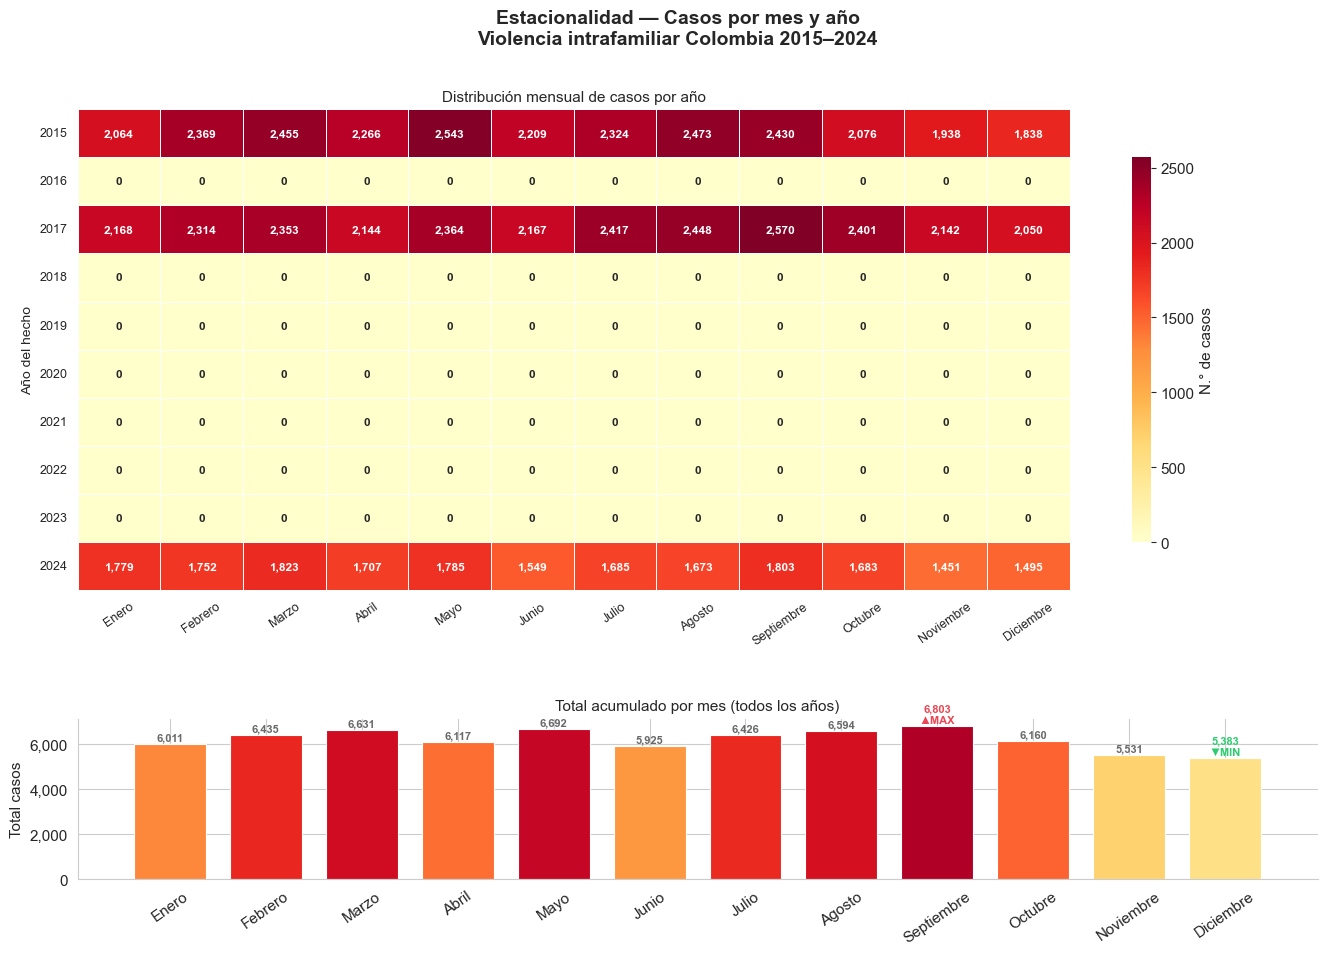

In [47]:
ORDEN_MES = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
             'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

pivot_mes = (df.groupby(['Año del hecho', 'Mes del hecho'])
               .size()
               .unstack('Mes del hecho')
               .reindex(columns=ORDEN_MES, fill_value=0))

fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.4})
fig.suptitle('Estacionalidad — Casos por mes y año\nViolencia intrafamiliar Colombia 2015–2024',
             fontsize=14, fontweight='bold')

# Heatmap principal
sns.heatmap(pivot_mes, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            ax=axes[0], annot_kws={'size': 8.5, 'weight': 'bold'},
            cbar_kws={'label': 'N.° de casos', 'shrink': 0.8})
axes[0].set_title('Distribución mensual de casos por año', fontsize=11, pad=6)
axes[0].set_xlabel('')
axes[0].set_ylabel('Año del hecho', fontsize=10)
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Total mensual acumulado (todos los años)
total_mes = pivot_mes.sum(axis=0)
bar_c_mes = [plt.cm.YlOrRd(0.2 + 0.7 * (v - total_mes.min()) / (total_mes.max() - total_mes.min()))
             for v in total_mes.values]
bars_m = axes[1].bar(ORDEN_MES, total_mes.values, color=bar_c_mes,
                     edgecolor='white', linewidth=0.8, width=0.75)
axes[1].set_title('Total acumulado por mes (todos los años)', fontsize=11)
axes[1].set_ylabel('Total casos')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top','right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=35)
# Resaltar el mes con más y menos casos
max_idx = total_mes.values.argmax()
min_idx = total_mes.values.argmin()
for i, (bar, val) in enumerate(zip(bars_m, total_mes.values)):
    color_lbl = PALETTE['accent'] if i == max_idx else (PALETTE['ok'] if i == min_idx else 'dimgray')
    label = f'{val:,}\n▲MAX' if i == max_idx else (f'{val:,}\n▼MIN' if i == min_idx else f'{val:,}')
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + total_mes.max()*0.01,
                 label, ha='center', va='bottom', fontsize=8,
                 fontweight='bold', color=color_lbl)

plt.savefig('eda_p1_heatmap_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()

### Pregunta 2: ¿Cuál es el perfil sociodemográfico de las víctimas?

*Motivación:* Conocer quiénes son las víctimas (sexo, ciclo vital, escolaridad, estado civil) ayuda a identificar los grupos más vulnerables y diseñar intervenciones diferenciadas. También se analiza el tipo de circunstancia para ver si hay patrones según el perfil de la víctima.

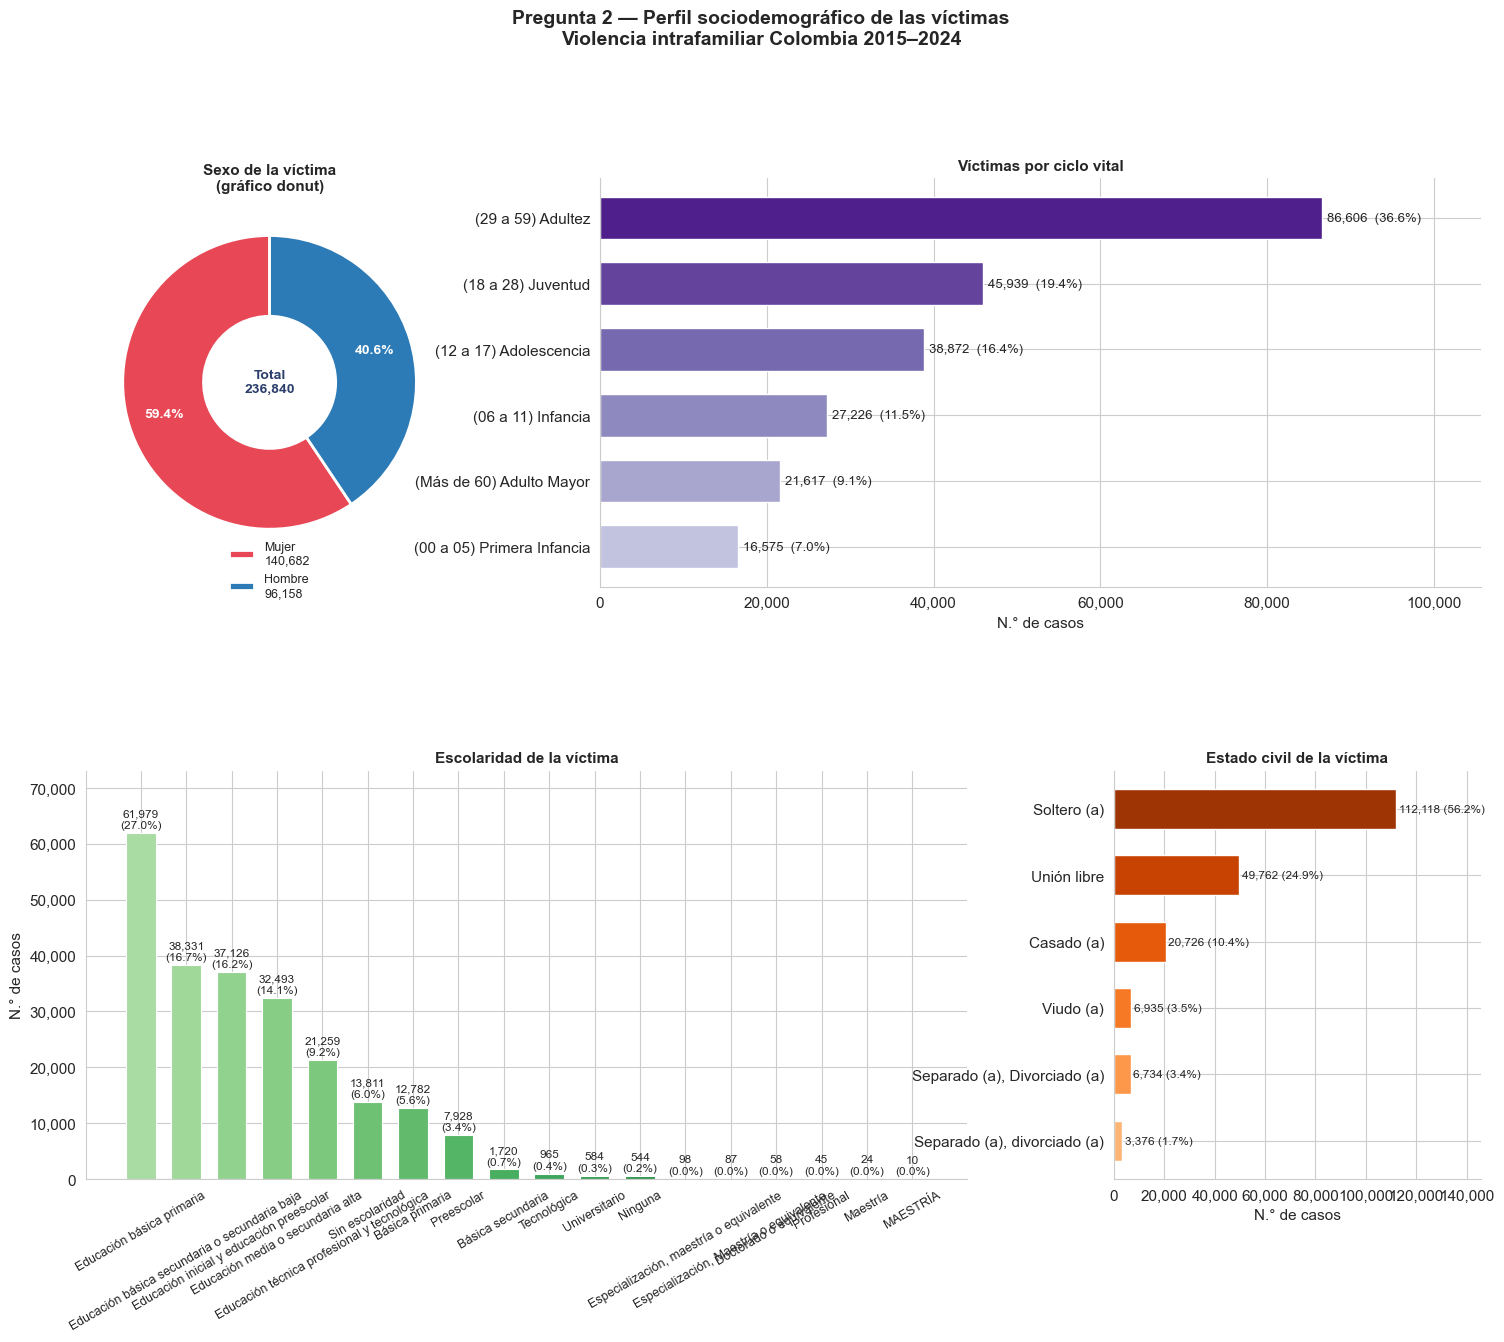

In [48]:
fig = plt.figure(figsize=(18, 13))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.4)
ax_pie   = fig.add_subplot(gs[0, 0])
ax_ciclo = fig.add_subplot(gs[0, 1:])
ax_escol = fig.add_subplot(gs[1, 0:2])
ax_civil = fig.add_subplot(gs[1, 2])

fig.suptitle('Pregunta 2 — Perfil sociodemográfico de las víctimas\n'
             'Violencia intrafamiliar Colombia 2015–2024',
             fontsize=14, fontweight='bold', y=1.01)

# ── Sexo: donut chart ─────────────────────────────────────────────────────────
sexo     = df['Sexo de la victima'].value_counts()
colores_sexo = ['#E84855', '#2C7BB6', '#ABB5BE'][:len(sexo)]
wedges, texts, autotexts = ax_pie.pie(
    sexo.values, labels=None, autopct='%1.1f%%',
    colors=colores_sexo, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2, width=0.55),
    pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
# Leyenda
ax_pie.legend(wedges, [f'{lbl}\n{n:,}' for lbl, n in zip(sexo.index, sexo.values)],
              loc='lower center', bbox_to_anchor=(0.5, -0.12),
              fontsize=9, frameon=False)
ax_pie.set_title('Sexo de la víctima\n(gráfico donut)', fontsize=11, fontweight='bold', pad=6)
ax_pie.text(0, 0, f'Total\n{len(df):,}', ha='center', va='center',
            fontsize=10, fontweight='bold', color=PALETTE['base'])

# ── Ciclo vital: barras horizontales con % ────────────────────────────────────
ciclo     = df_clean['Ciclo Vital'].dropna().value_counts().sort_values()
pct_ciclo = (ciclo / ciclo.sum() * 100).round(1)
cmap_ciclo = plt.cm.Purples
nc = len(ciclo)
col_ciclo  = [cmap_ciclo(0.35 + 0.55 * i / max(nc - 1, 1)) for i in range(nc)]

bars_c = ax_ciclo.barh(ciclo.index, ciclo.values, color=col_ciclo,
                       edgecolor='white', height=0.65)
for bar, val, p in zip(bars_c, ciclo.values, pct_ciclo.values):
    ax_ciclo.text(bar.get_width() + ciclo.max()*0.007,
                  bar.get_y() + bar.get_height()/2,
                  f'{val:,}  ({p}%)', va='center', fontsize=9.5)
ax_ciclo.set_title('Víctimas por ciclo vital', fontsize=11, fontweight='bold', pad=6)
ax_ciclo.set_xlabel('N.° de casos')
ax_ciclo.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_ciclo.spines[['top','right']].set_visible(False)
ax_ciclo.set_xlim(0, ciclo.max() * 1.22)

# ── Escolaridad: barras verticales con etiquetas + % ─────────────────────────
escol     = df_clean['Escolaridad'].dropna().value_counts()
pct_escol = (escol / escol.sum() * 100).round(1)
cmap_e    = plt.cm.Greens
col_e     = [cmap_e(0.35 + 0.55 * i / max(len(escol) - 1, 1)) for i in range(len(escol))]

bars_e = ax_escol.bar(escol.index, escol.values, color=col_e,
                      edgecolor='white', linewidth=0.8, width=0.65)
for bar, val, p in zip(bars_e, escol.values, pct_escol.values):
    ax_escol.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + escol.max()*0.008,
                  f'{val:,}\n({p}%)', ha='center', va='bottom', fontsize=8.5)
ax_escol.set_title('Escolaridad de la víctima', fontsize=11, fontweight='bold', pad=6)
ax_escol.set_ylabel('N.° de casos')
ax_escol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_escol.spines[['top','right']].set_visible(False)
ax_escol.tick_params(axis='x', rotation=30, labelsize=9)
ax_escol.set_ylim(0, escol.max() * 1.18)

# ── Estado civil: barras horizontales ────────────────────────────────────────
est_civil  = df_clean['Estado Civil'].dropna().value_counts().sort_values()
pct_civil  = (est_civil / est_civil.sum() * 100).round(1)
cmap_cv    = plt.cm.Oranges
col_cv     = [cmap_cv(0.35 + 0.55 * i / max(len(est_civil) - 1, 1)) for i in range(len(est_civil))]

bars_cv = ax_civil.barh(est_civil.index, est_civil.values, color=col_cv,
                        edgecolor='white', height=0.6)
for bar, val, p in zip(bars_cv, est_civil.values, pct_civil.values):
    ax_civil.text(bar.get_width() + est_civil.max()*0.008,
                  bar.get_y() + bar.get_height()/2,
                  f'{val:,} ({p}%)', va='center', fontsize=8.5)
ax_civil.set_title('Estado civil de la víctima', fontsize=11, fontweight='bold', pad=6)
ax_civil.set_xlabel('N.° de casos')
ax_civil.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_civil.spines[['top','right']].set_visible(False)
ax_civil.set_xlim(0, est_civil.max() * 1.3)

plt.savefig('eda_p2_perfil_victimas.png', dpi=150, bbox_inches='tight')
plt.show()

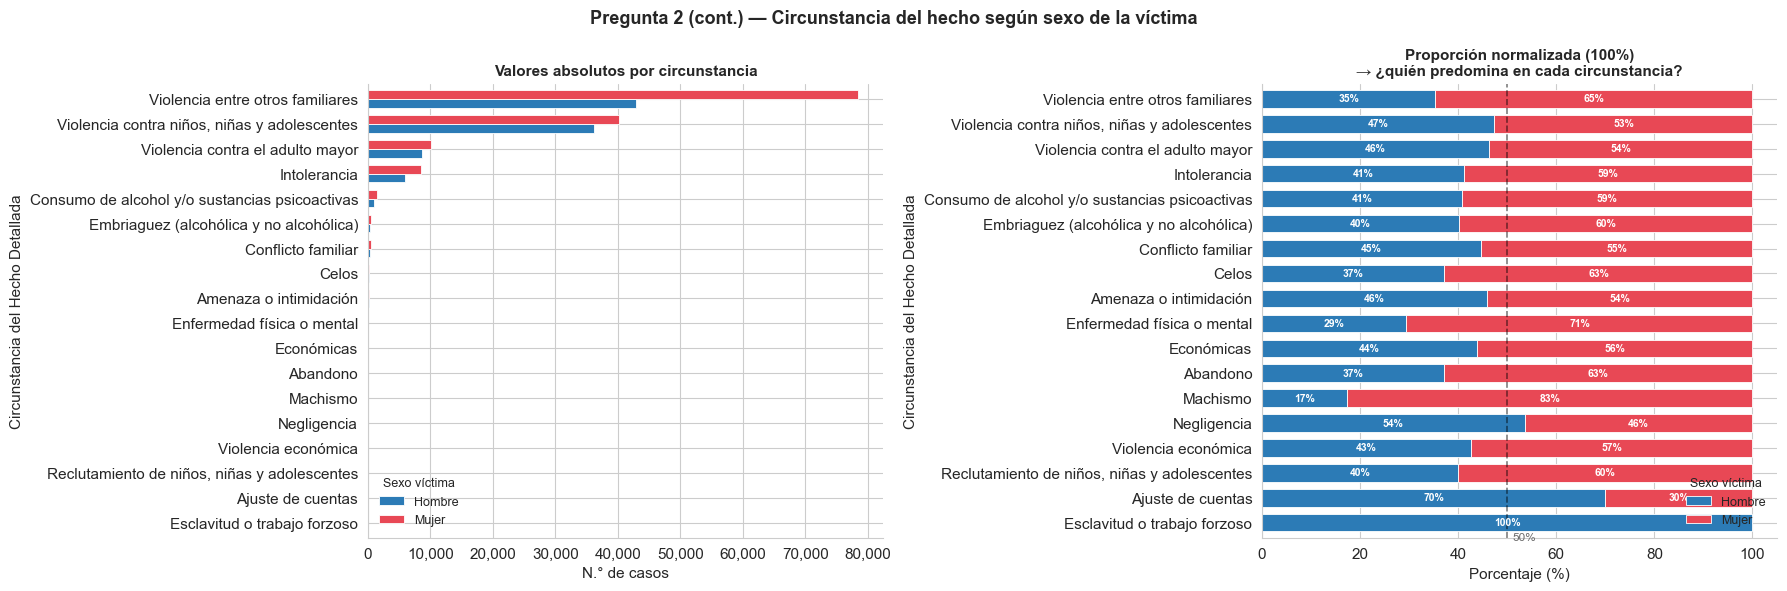

In [49]:
# Circunstancia del hecho × Sexo — barras agrupadas + versión normalizada
COL_CIRC = 'Circunstancia del Hecho Detallada'   # nombre real en el dataset

circ_sexo = (df_clean[['Sexo de la victima', COL_CIRC]]
             .dropna()
             .groupby([COL_CIRC, 'Sexo de la victima'])
             .size()
             .unstack('Sexo de la victima')
             .fillna(0)
             .sort_values(by=df_clean['Sexo de la victima'].dropna().value_counts().index[0]))

circ_pct = circ_sexo.div(circ_sexo.sum(axis=1), axis=0) * 100

sex_colors = {'Mujer': '#E84855', 'Hombre': '#2C7BB6', 'Intersexual': '#ABB5BE',
              'No definido': '#ABB5BE'}
cols_plot = [sex_colors.get(c, '#888') for c in circ_sexo.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Pregunta 2 (cont.) — Circunstancia del hecho según sexo de la víctima',
             fontsize=13, fontweight='bold')

# Absolutos
circ_sexo.plot(kind='barh', ax=axes[0], color=cols_plot,
               edgecolor='white', linewidth=0.6, width=0.7)
axes[0].set_title('Valores absolutos por circunstancia', fontsize=11, fontweight='bold')
axes[0].set_xlabel('N.° de casos')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(title='Sexo víctima', fontsize=9, title_fontsize=9, frameon=False)

# Normalizado
circ_pct.plot(kind='barh', stacked=True, ax=axes[1], color=cols_plot,
              edgecolor='white', linewidth=0.6, width=0.7)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
axes[1].text(51, -0.7, '50%', fontsize=8.5, color='dimgray')
axes[1].set_title('Proporción normalizada (100%)\n→ ¿quién predomina en cada circunstancia?',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(title='Sexo víctima', fontsize=9, title_fontsize=9,
               loc='lower right', frameon=False)
# Etiquetas % en segmentos >8%
for i, (idx, row) in enumerate(circ_pct.iterrows()):
    acum = 0
    for col, val in row.items():
        if val > 8:
            axes[1].text(acum + val / 2, i, f'{val:.0f}%',
                         ha='center', va='center', fontsize=7.5,
                         color='white', fontweight='bold')
        acum += val

plt.tight_layout()
plt.savefig('eda_p2_circunstancia_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

### Pregunta 3: ¿Cuáles son los principales factores de riesgo asociados a la violencia intrafamiliar (agresor, factor desencadenante, escenario y mecanismo)?

*Motivación:* Identificar quién agrede, en qué escenario, bajo qué circunstancia y con qué mecanismo permite proponer estrategias de prevención focalizadas. También se cruza el factor desencadenante con el perfil del agresor para detectar combinaciones críticas.

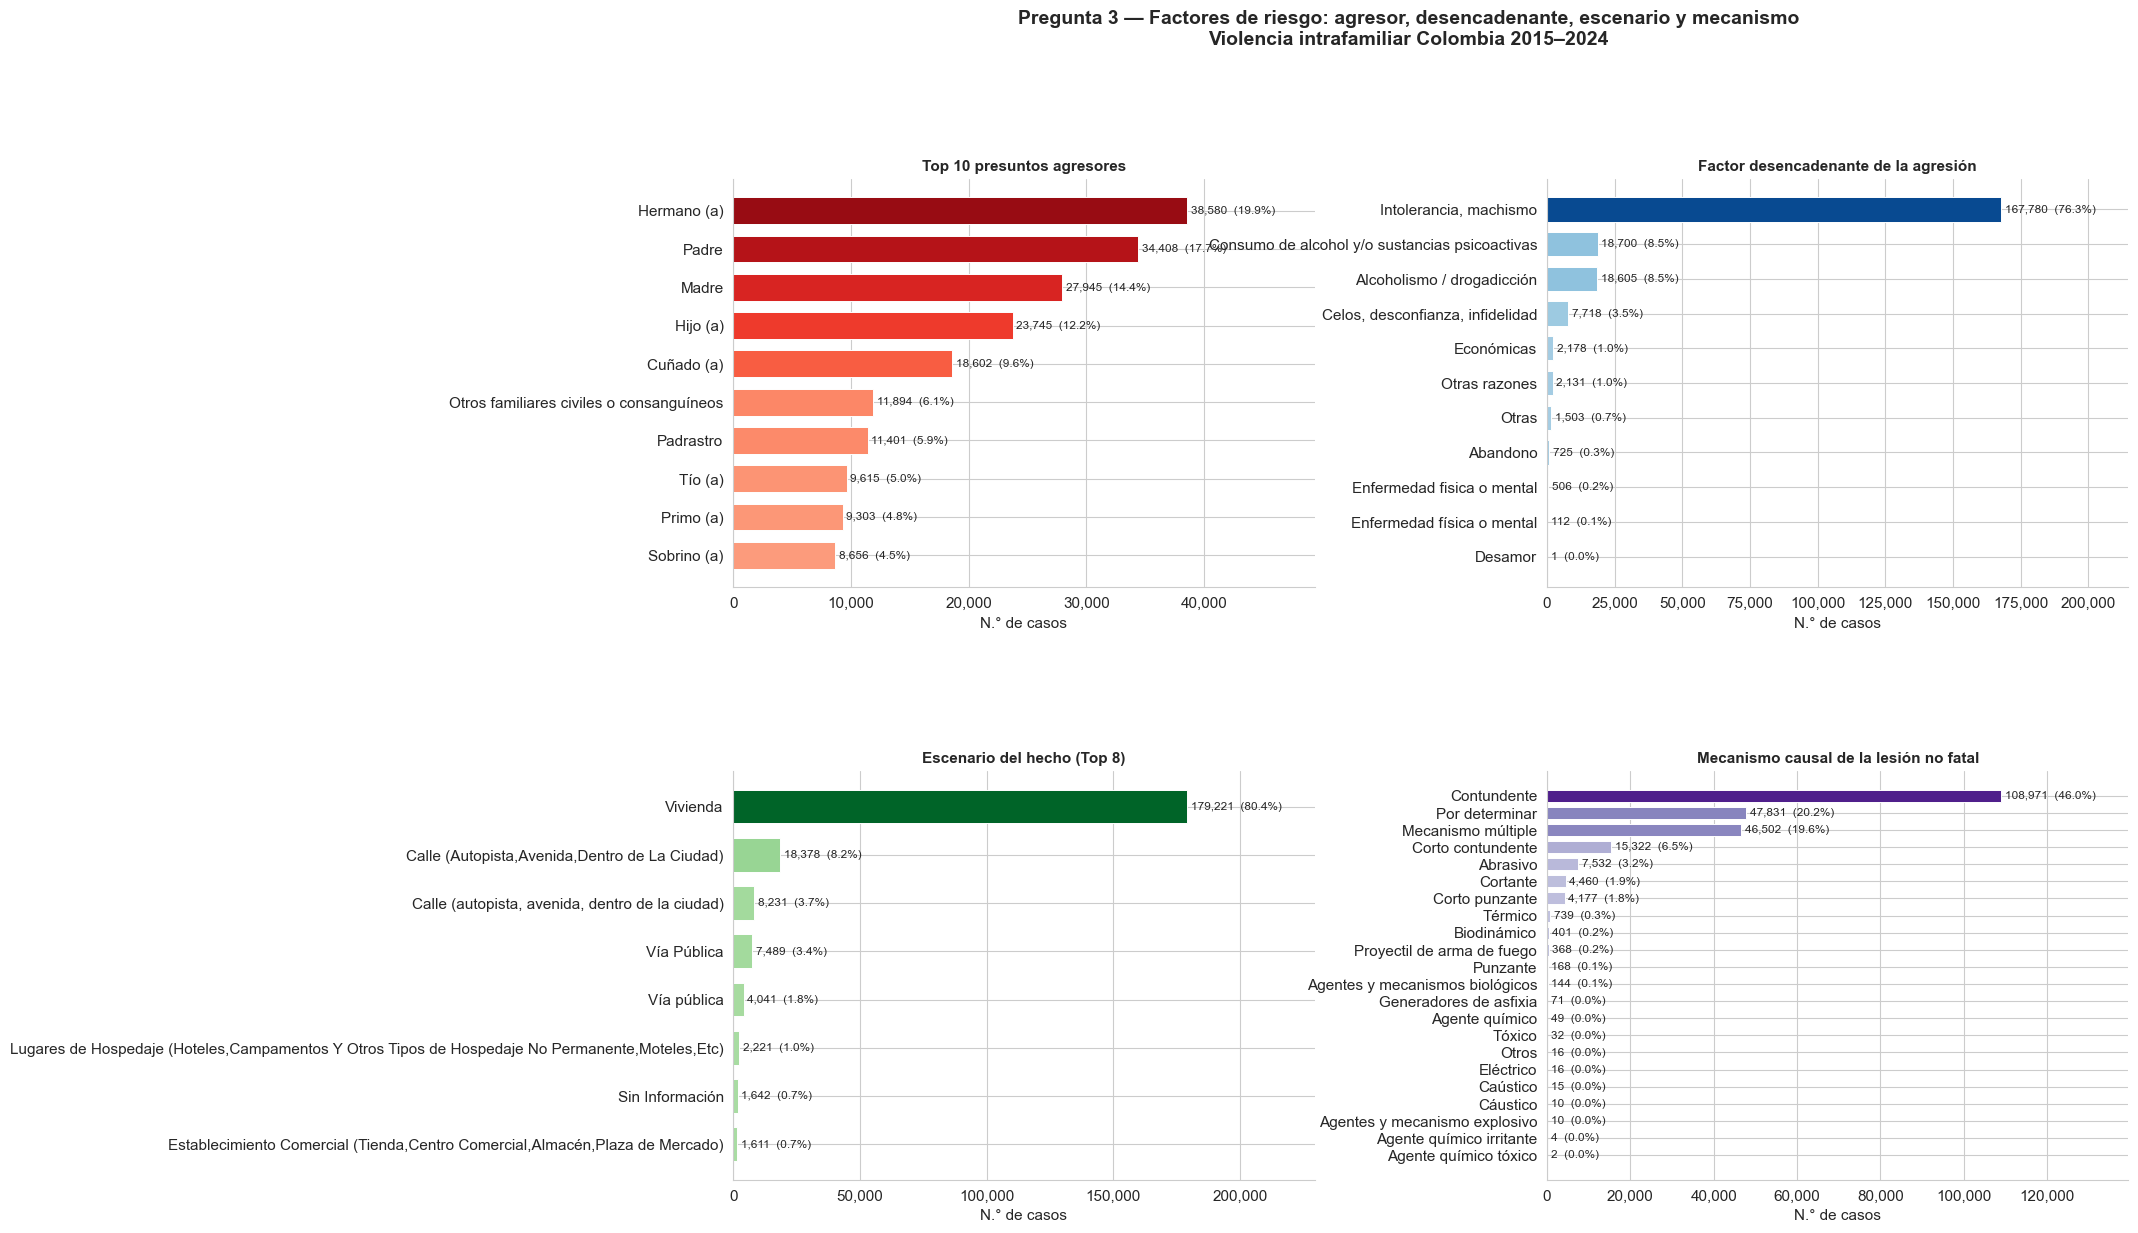

In [50]:
fig = plt.figure(figsize=(18, 13))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.4)
ax_agr = fig.add_subplot(gs[0, 0])
ax_fac = fig.add_subplot(gs[0, 1])
ax_esc = fig.add_subplot(gs[1, 0])
ax_mec = fig.add_subplot(gs[1, 1])

fig.suptitle('Pregunta 3 — Factores de riesgo: agresor, desencadenante, escenario y mecanismo\n'
             'Violencia intrafamiliar Colombia 2015–2024',
             fontsize=14, fontweight='bold', y=1.01)

def barh_styled(ax, series, cmap_name, title, xlabel='N.° de casos'):
    """Helper para barras horizontales con gradiente y etiquetas."""
    pct   = (series / series.sum() * 100).round(1)
    cmap_ = plt.get_cmap(cmap_name)
    norm_ = (series.values - series.min()) / max(series.max() - series.min(), 1)
    cols_ = [cmap_(0.35 + 0.55 * v) for v in norm_]
    bars_ = ax.barh(series.index, series.values, color=cols_,
                    edgecolor='white', linewidth=0.7, height=0.7)
    for bar, val, p in zip(bars_, series.values, pct.values):
        ax.text(bar.get_width() + series.max() * 0.008,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}  ({p}%)', va='center', fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, series.max() * 1.28)

# ── Top 10 agresores ──────────────────────────────────────────────────────────
agresor = df_clean['Presunto Agresor Detallado'].dropna().value_counts().head(10).sort_values()
barh_styled(ax_agr, agresor, 'Reds', 'Top 10 presuntos agresores')

# ── Factor desencadenante ─────────────────────────────────────────────────────
factor = df_clean['Factor Desencadenante de la Agresión'].dropna().value_counts().sort_values()
barh_styled(ax_fac, factor, 'Blues', 'Factor desencadenante de la agresión')

# ── Escenario ─────────────────────────────────────────────────────────────────
escenario = df_clean['Escenario del Hecho'].dropna().value_counts().head(8).sort_values()
barh_styled(ax_esc, escenario, 'Greens', 'Escenario del hecho (Top 8)')

# ── Mecanismo causal ──────────────────────────────────────────────────────────
mec = df_clean['Mecanismo Causal de la Lesión no Fatal'].dropna().value_counts().sort_values()
barh_styled(ax_mec, mec, 'Purples', 'Mecanismo causal de la lesión no fatal')

plt.savefig('eda_p3_factores_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

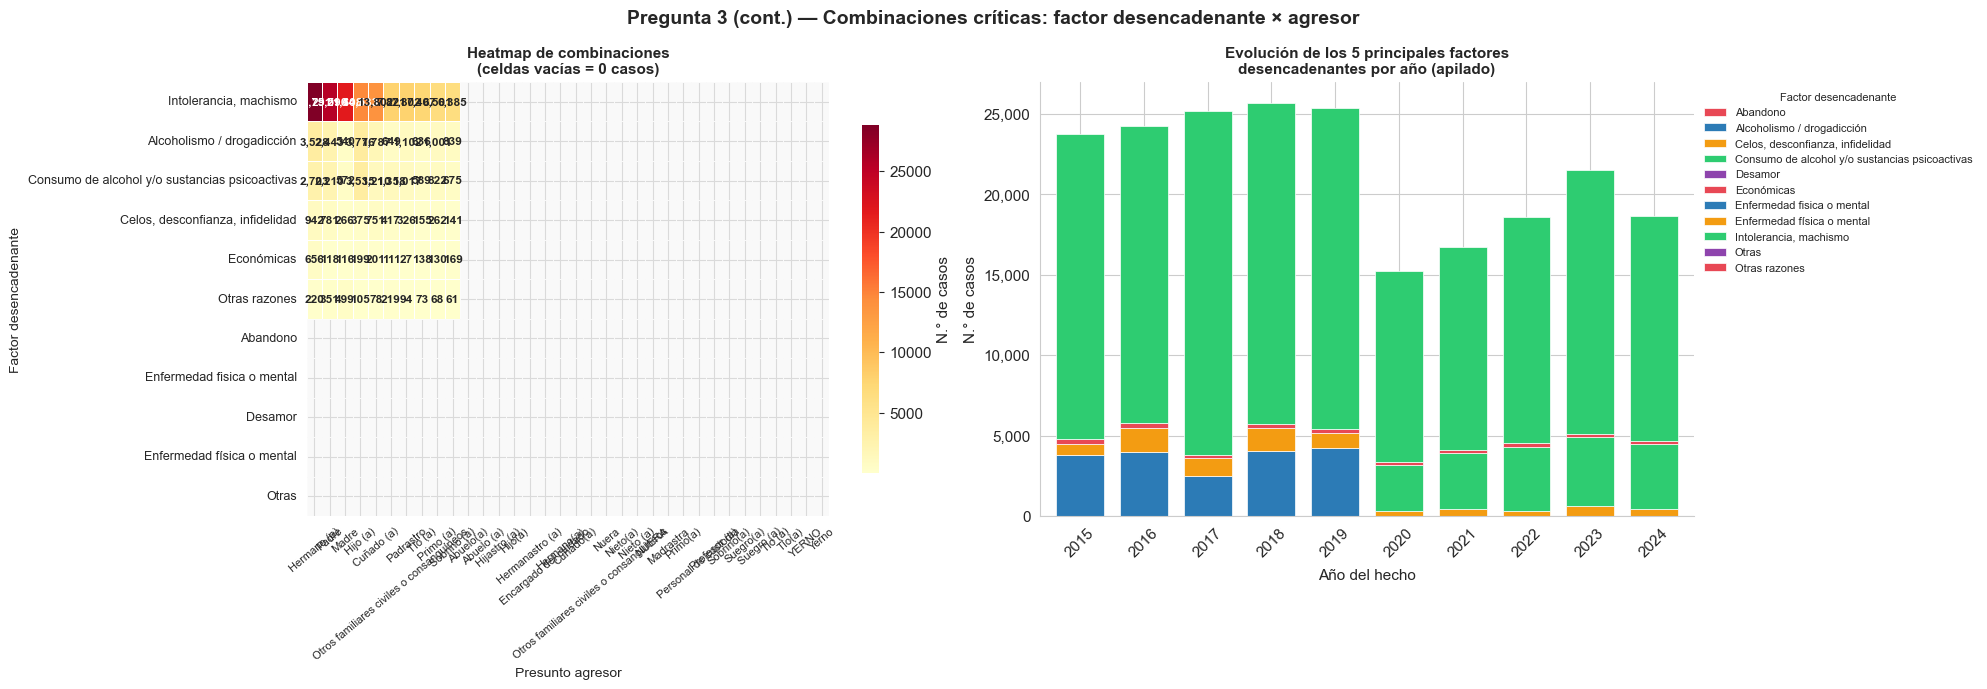

In [51]:
# Heatmap cruzado: Factor desencadenante × Presunto agresor
# + gráfico de barras apiladas por año del factor principal
sub = df_clean[['Factor Desencadenante de la Agresión',
                'Presunto Agresor Detallado']].dropna()

top_factores = sub['Factor Desencadenante de la Agresión'].value_counts().head(6).index
top_agresores = sub['Presunto Agresor Detallado'].value_counts().head(10).index

pivot_fa = (sub[sub['Factor Desencadenante de la Agresión'].isin(top_factores) &
               sub['Presunto Agresor Detallado'].isin(top_agresores)]
            .groupby(['Factor Desencadenante de la Agresión', 'Presunto Agresor Detallado'])
            .size()
            .unstack('Presunto Agresor Detallado')
            .fillna(0)
            .astype(int))

# Ordenar filas y columnas por total descendente
pivot_fa = pivot_fa.loc[pivot_fa.sum(axis=1).sort_values(ascending=False).index,
                        pivot_fa.sum(axis=0).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Pregunta 3 (cont.) — Combinaciones críticas: factor desencadenante × agresor',
             fontsize=14, fontweight='bold')

# Heatmap con anotaciones y máscara para ceros
mask = (pivot_fa == 0)
sns.heatmap(pivot_fa, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            ax=axes[0], annot_kws={'size': 8.5, 'weight': 'bold'},
            mask=mask,
            cbar_kws={'label': 'N.° de casos', 'shrink': 0.8})
# Celdas con cero en gris
sns.heatmap(pivot_fa, annot=False, cmap=['#f0f0f0'], alpha=0.4,
            linewidths=0.4, linecolor='white', ax=axes[0], mask=~mask,
            cbar=False)
axes[0].set_title('Heatmap de combinaciones\n(celdas vacías = 0 casos)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Presunto agresor', fontsize=10)
axes[0].set_ylabel('Factor desencadenante', fontsize=10)
axes[0].tick_params(axis='x', rotation=40, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Barras apiladas: top 5 factores por año
sub2 = df_clean[['Año del hecho', 'Factor Desencadenante de la Agresión']].copy()
sub2['Año del hecho'] = df['Año del hecho']
sub2 = sub2.dropna(subset=['Factor Desencadenante de la Agresión'])

top5_fac = sub2['Factor Desencadenante de la Agresión'].value_counts().head(5).index
pivot_year = (sub2[sub2['Factor Desencadenante de la Agresión'].isin(top5_fac)]
              .groupby(['Año del hecho', 'Factor Desencadenante de la Agresión'])
              .size()
              .unstack('Factor Desencadenante de la Agresión')
              .fillna(0))

colores_fac = ['#E84855', '#2C7BB6', '#F39C12', '#2ECC71', '#8E44AD'][:len(pivot_year.columns)]
pivot_year.plot(kind='bar', stacked=True, ax=axes[1],
                color=colores_fac, edgecolor='white', linewidth=0.5, width=0.75)
axes[1].set_title('Evolución de los 5 principales factores\ndesencadenantes por año (apilado)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Año del hecho', labelpad=6)
axes[1].set_ylabel('N.° de casos')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(title='Factor desencadenante', fontsize=8, title_fontsize=8,
               bbox_to_anchor=(1, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('eda_p3_heatmap_factor_agresor.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resumen ejecutivo del EDA

| Dimensión | Hallazgo esperado |
|---|---|
| **Temporal** | Identificar si los casos crecen año a año y si 2020 (pandemia) muestra un cambio. |
| **Geográfica** | Bogotá, Antioquia y Valle del Cauca concentran la mayoría de casos por volumen poblacional. |
| **Perfil víctima** | Mayoría de mujeres adultas; el ciclo vital de adultez (29–59 años) es el más afectado. |
| **Agresor** | Pareja/cónyuge y padres son los principales agresores; el escenario predominante es la vivienda. |
| **Factor desencadenante** | Intolerancia/machismo es el factor más frecuente, seguido de alcoholismo/drogadicción. |
| **Mecanismo** | El mecanismo contundente (golpes) es el más reportado en lesiones no fatales. |

> **Nota sobre calidad de datos:** Columnas como `Localidad del Hecho`, `Orientación Sexual` e `Identidad de Género` presentan alto porcentaje de "Sin información" (>30%), lo que limita análisis específicos sobre esas dimensiones.